### Import Library and data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/tourism_arrivals_clean.csv"
)

yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly 

,Year,Tourist_Arrivals
0,2018,2333796.0
1,2019,1913702.0
2,2020,507699.0
3,2021,194495.0
4,2022,719978.0
5,2023,1487303.0
6,2024,2053465.0
7,2025,2362521.0


### Line chart

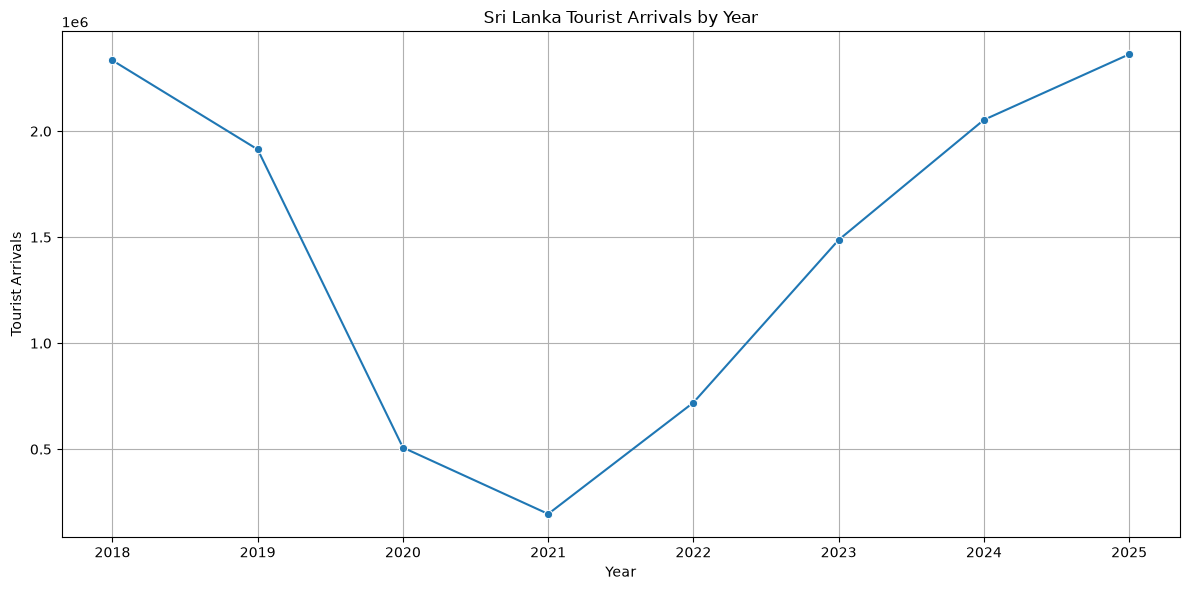

In [4]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Tourist_Arrivals",
    marker="o"
)

plt.title("Sri Lanka Tourist Arrivals by Year")
plt.xlabel("Year")
plt.ylabel("Tourist Arrivals")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/yearly_tourism_performance.png",
    dpi=300
)

plt.show()

### Year over Year Growth Analysis

In [5]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly["YoY_Growth_%"] = (
    yearly["Tourist_Arrivals"]
    .pct_change()
    * 100
)

yearly

,Year,Tourist_Arrivals,YoY_Growth_%
0,2018,2333796.0,NaN
1,2019,1913702.0,-18.000459
2,2020,507699.0,-73.470321
3,2021,194495.0,-61.690884
4,2022,719978.0,270.178154
5,2023,1487303.0,106.576173
6,2024,2053465.0,38.066352
7,2025,2362521.0,15.050463


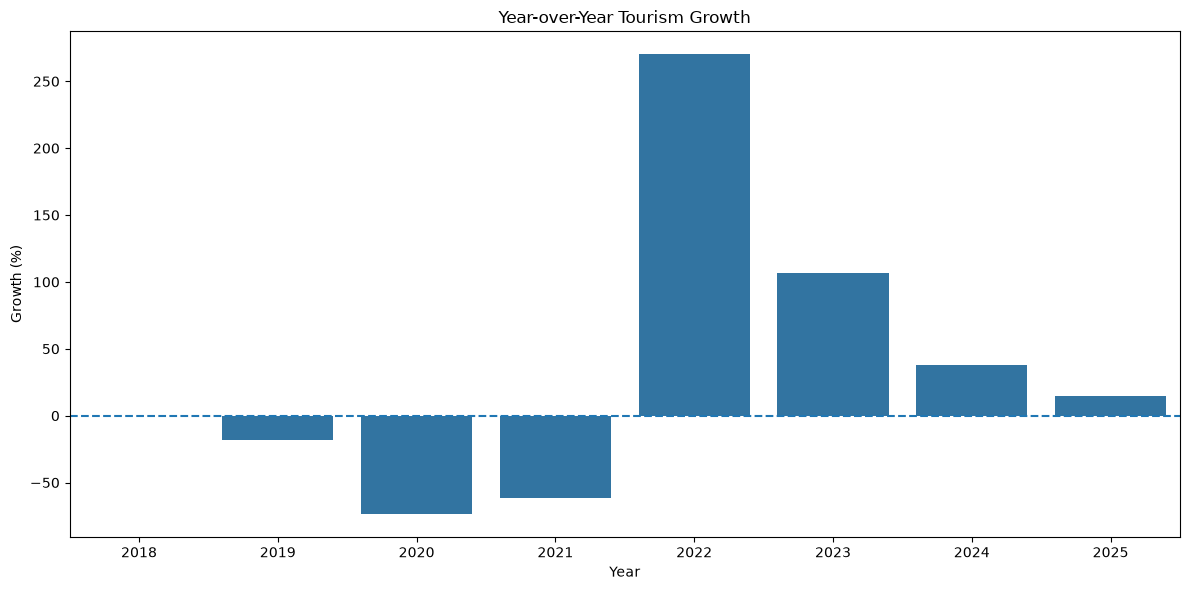

In [6]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=yearly,
    x="Year",
    y="YoY_Growth_%"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Year-over-Year Tourism Growth")
plt.ylabel("Growth (%)")

plt.tight_layout()
plt.show()

### Monthly and Seasonality Analysis

In [7]:
monthly = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)

monthly

,Month_Number,Month,Tourist_Arrivals
0,1,January,1359164.0
1,2,February,1361234.0
2,3,March,1224134.0
3,4,April,843525.0
4,5,May,527328.0
5,6,June,596469.0
6,7,July,914345.0
7,8,August,885995.0
8,9,September,694060.0
9,10,October,746962.0


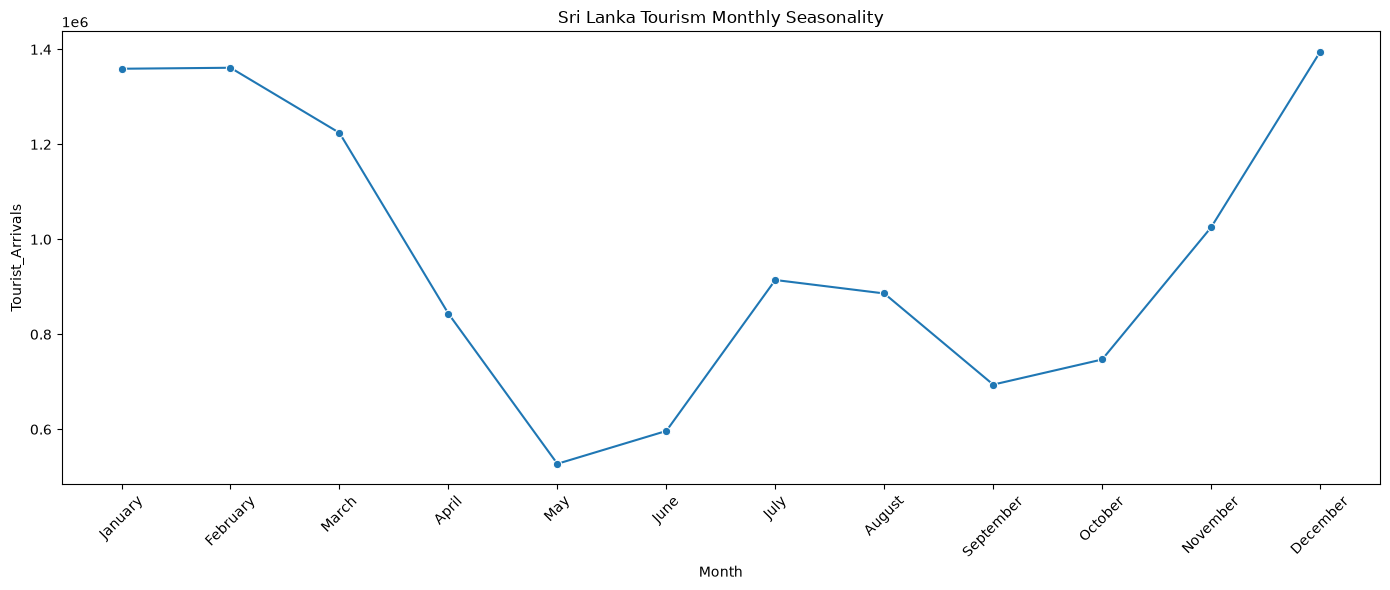

In [8]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly,
    x="Month",
    y="Tourist_Arrivals",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Sri Lanka Tourism Monthly Seasonality")

plt.tight_layout()
plt.show()

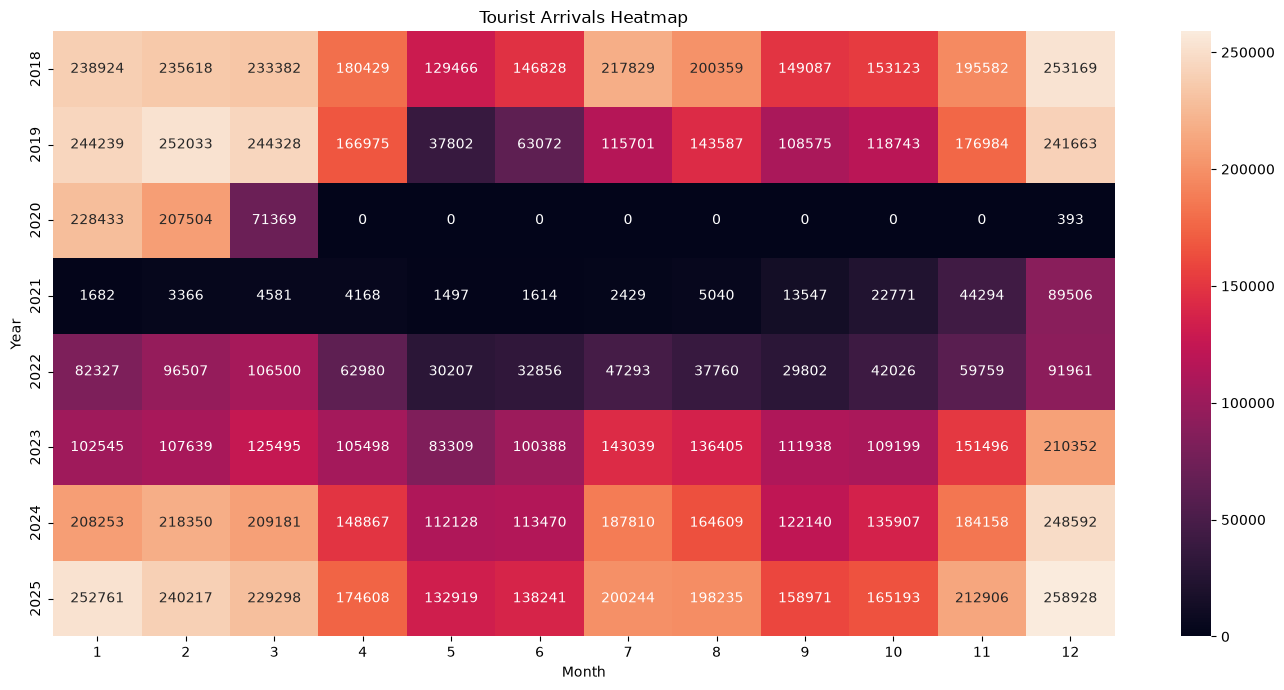

In [9]:
heatmap_data = df.pivot_table(
    index="Year",
    columns="Month_Number",
    values="Tourist_Arrivals",
    aggfunc="sum"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f"
)

plt.title("Tourist Arrivals Heatmap")

plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

### Country_Market_Analysis

In [10]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

country.head(20)

,Country,Tourist_Arrivals
234,India,1374333.0
416,Russian Federation,677270.0
541,United Kingdom,605891.0
531,UNITED KINGDOM,525053.0
220,INDIA,500627.0
198,Germany,442131.0
221,"INDIA, REPUBLIC OF",424887.0
182,GERMANY,338736.0
119,China,337220.0
31,Australia,297420.0


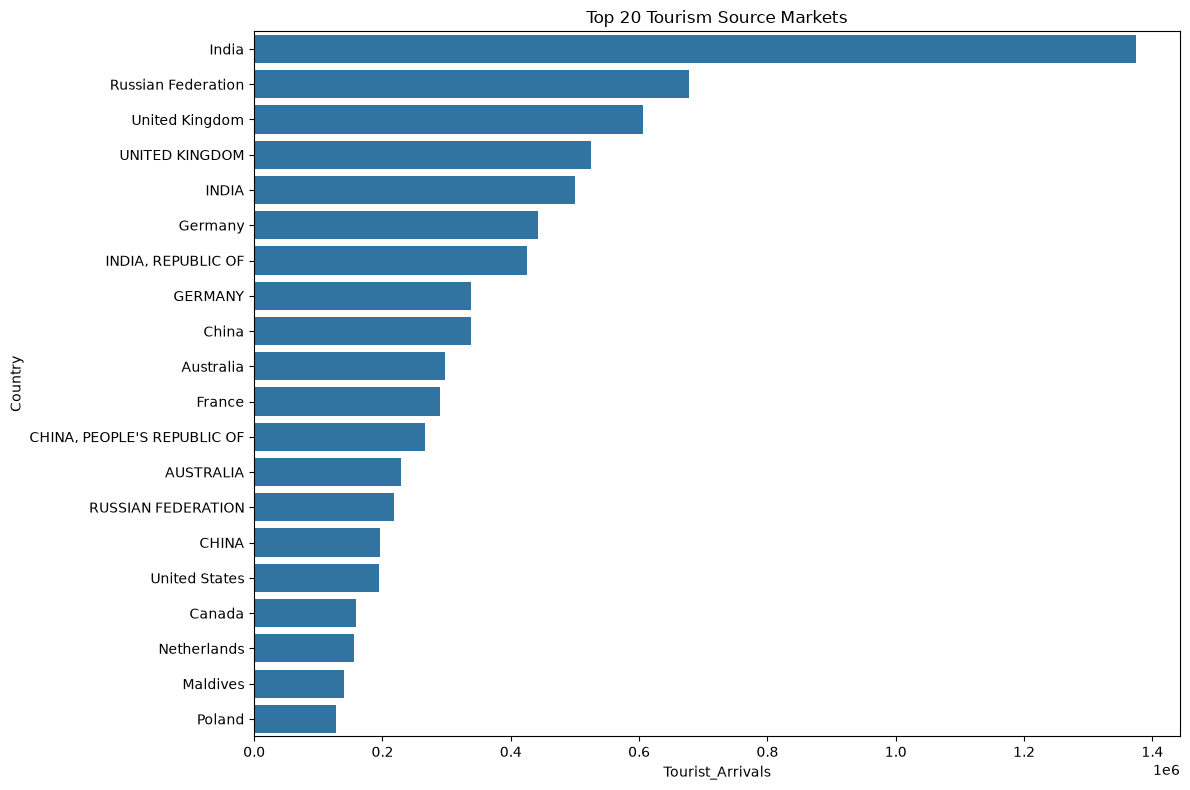

In [11]:
top20 = country.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top20,
    y="Country",
    x="Tourist_Arrivals"
)

plt.title("Top 20 Tourism Source Markets")

plt.tight_layout()
plt.show()

### Country_Market_Share_Analysis

In [12]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

total_arrivals = country[
    "Tourist_Arrivals"
].sum()

country["Market_Share_%"] = (
    country["Tourist_Arrivals"]
    / total_arrivals
    * 100
)

country = country.sort_values(
    "Market_Share_%",
    ascending=False
)

country.head(20)

,Country,Tourist_Arrivals,Market_Share_%
234,India,1374333.0,11.875381
416,Russian Federation,677270.0,5.852177
541,United Kingdom,605891.0,5.235403
531,UNITED KINGDOM,525053.0,4.536895
220,INDIA,500627.0,4.325834
198,Germany,442131.0,3.820380
221,"INDIA, REPUBLIC OF",424887.0,3.671377
182,GERMANY,338736.0,2.926961
119,China,337220.0,2.913862
31,Australia,297420.0,2.569956


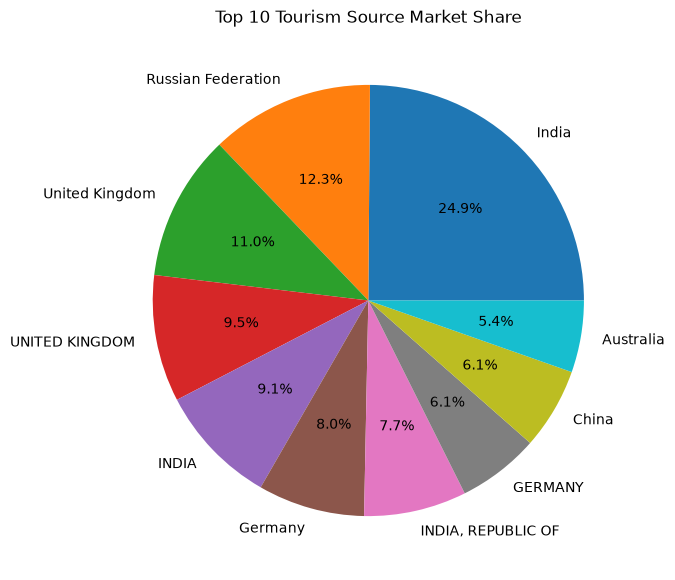

In [13]:
top10 = country.head(10)

plt.figure(figsize=(10, 7))

plt.pie(
    top10["Market_Share_%"],
    labels=top10["Country"],
    autopct="%1.1f%%"
)

plt.title(
    "Top 10 Tourism Source Market Share"
)

plt.show()

### Country_Growth_Analysis

In [14]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Growth_%"] = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .pct_change()
    * 100
)

country_year.head()

,Country,Year,Tourist_Arrivals,Growth_%
0,A,2021,0.0,NaN
1,AFGHANISTAN,2019,473.0,NaN
2,AFGHANISTAN,2020,146.0,-69.133192
3,AFGHANISTAN,2021,15.0,-89.726027
4,"AFGHANISTAN, ISLAMIC REPUBLIC OF",2018,861.0,NaN


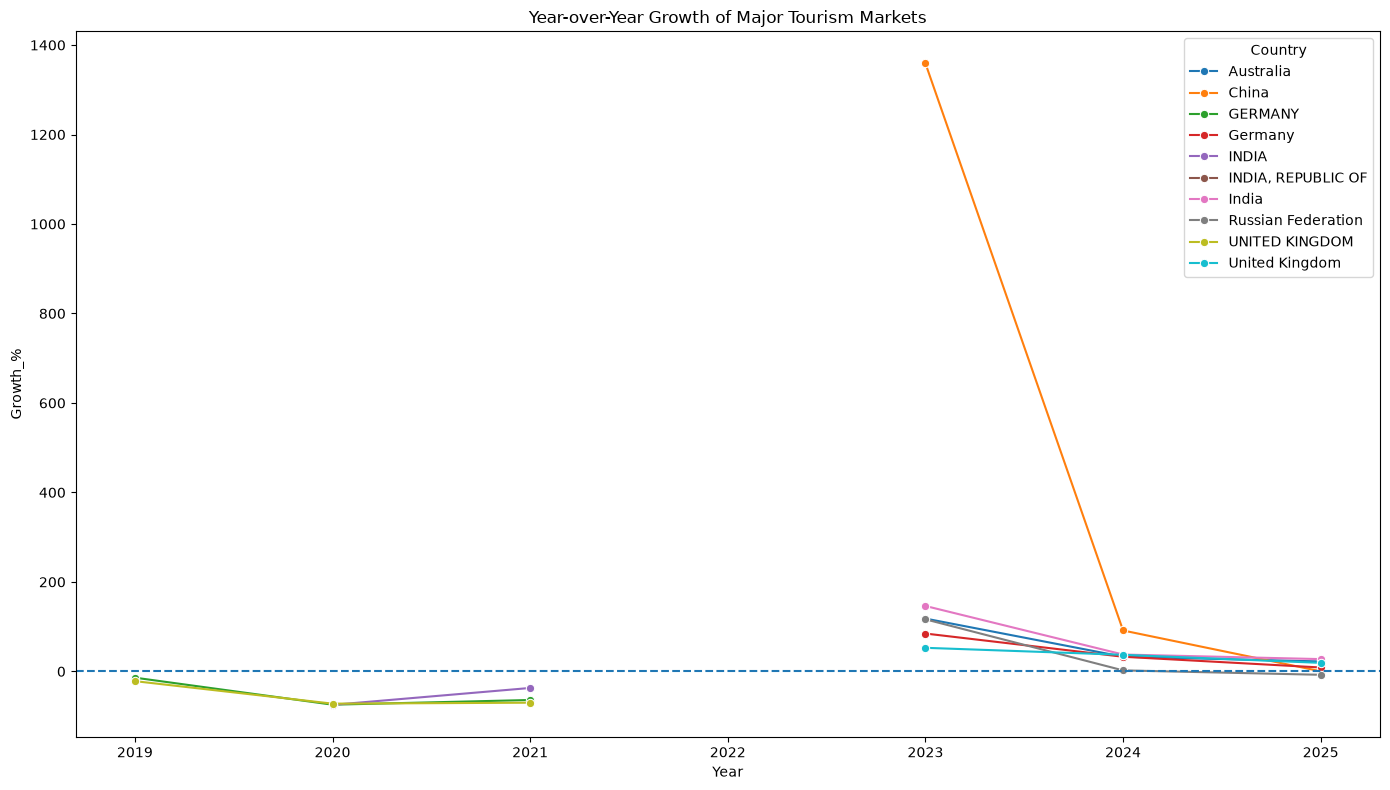

In [15]:
top_countries = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .sum()
    .nlargest(10)
    .index
)

growth_top = country_year[
    country_year["Country"].isin(top_countries)
]

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=growth_top,
    x="Year",
    y="Growth_%",
    hue="Country",
    marker="o"
)

plt.title(
    "Year-over-Year Growth of Major Tourism Markets"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

### Country_Ranking_Analysis

In [16]:
country_year = (
    df.groupby(
        ["Year", "Country"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Rank"] = (
    country_year
    .groupby("Year")["Tourist_Arrivals"]
    .rank(
        method="min",
        ascending=False
    )
)

country_year["Rank"] = (
    country_year["Rank"]
    .astype(int)
)

country_year.head()

,Year,Country,Tourist_Arrivals,Rank
0,2018,"AFGHANISTAN, ISLAMIC REPUBLIC OF",861.0,77
1,2018,"ALBANIA, REPUBLIC OF",177.0,106
2,2018,"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",368.0,94
3,2018,"ANDORRA, PRINCIPALITY OF",53.0,131
4,2018,"ANGOLA, REPUBLIC OF",9.0,173


In [17]:
top10_each_year = country_year[
    country_year["Rank"] <= 10
].sort_values(
    ["Year", "Rank"]
)

top10_each_year

,Year,Country,Tourist_Arrivals,Rank
74,2018,"INDIA, REPUBLIC OF",424887.0,1
35,2018,"CHINA, PEOPLE'S REPUBLIC OF",265965.0,2
186,2018,UNITED KINGDOM,254176.0,3
62,2018,GERMANY,156888.0,4
8,2018,AUSTRALIA,110928.0,5
...,...,...,...,...
1372,2025,Australia,109487.0,6
1423,2025,France,109041.0,7
1550,2025,United States,65973.0,8
1484,2025,Netherlands,64164.0,9


### Country_Month_Behavior_Analysis

In [18]:
country_month = (
    df.groupby(
        ["Country", "Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_month.head()

,Country,Month_Number,Month,Tourist_Arrivals
0,A,1,January,0.0
1,A,2,February,0.0
2,A,3,March,0.0
3,A,4,April,0.0
4,A,5,May,0.0


In [19]:
selected_country = "India"

india = country_month[
    country_month["Country"].str.upper()
    == selected_country.upper()
]

india

,Country,Month_Number,Month,Tourist_Arrivals
2640,INDIA,1,January,81514.0
2641,INDIA,2,February,67674.0
2642,INDIA,3,March,47595.0
2643,INDIA,4,April,24227.0
2644,INDIA,5,May,11285.0
2645,INDIA,6,June,15053.0
2646,INDIA,7,July,18317.0
2647,INDIA,8,August,37973.0
2648,INDIA,9,September,37445.0
2649,INDIA,10,October,41623.0


NameError: name 'Month' is not defined

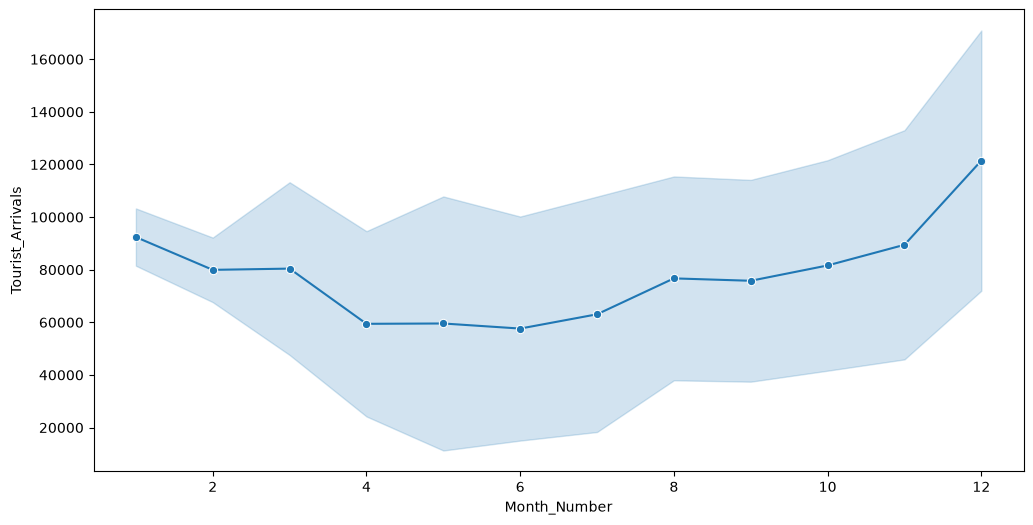

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=india,
    x="Month_Number",
    y="Tourist_Arrivals",
    marker="o"
)

plt.xticks(
    range(1, 13),
    Month,
    rotation=45
)

plt.title(
    f"Monthly Tourism Behavior - {selected_country}"
)

plt.tight_layout()
plt.show()

### Regional Market Analysis

In [23]:
import country_converter as coco

In [24]:
df["Continent"] = coco.convert(
    df["Country"],
    to="continent",
    not_found=None
)

df[
    ["Country", "Continent"]
].drop_duplicates().head(20)

NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
Country not found in regex
KOSOVAR not found in regex
Country not found in regex
KOSOVAR not found in regex
Coun

,Country,Continent
0,"AFGHANISTAN, ISLAMIC REPUBLIC OF",Asia
1,"ALBANIA, REPUBLIC OF",Europe
2,"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",Africa
3,"ANDORRA, PRINCIPALITY OF",Europe
4,"ANGOLA, REPUBLIC OF",Africa
5,ANTIGUA & BARBUDA,America
6,ARGENTINA,America
7,"ARMENIA, REPUBLIC OF",Asia
8,AUSTRALIA,Oceania
9,AUSTRIA,Europe


In [25]:
continent_summary = (
    df.groupby("Continent")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

continent_summary

,Continent,Tourist_Arrivals
14,Europe,5431692.0
4,Asia,4761506.0
2,America,683844.0
29,Oceania,592095.0
1,Africa,103639.0
22,Kosovar,96.0
21,KOSOVAR,53.0
8,Cote d'lvoire,15.0
35,SOLOMAN ISLANDS,13.0
27,Netherlands Antilles,2.0


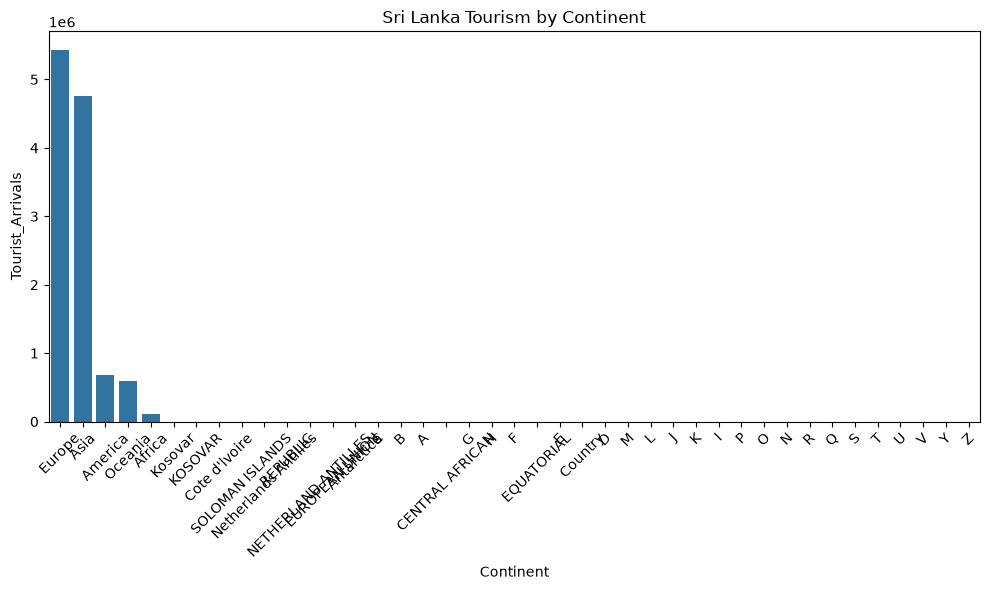

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=continent_summary,
    x="Continent",
    y="Tourist_Arrivals"
)

plt.title(
    "Sri Lanka Tourism by Continent"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()